In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import re

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import f1_score, matthews_corrcoef, precision_score, recall_score, accuracy_score

In [3]:
patterns = [r"\*\*Verdict:\*\*\s*(Buggy|NotBuggy)", r"\*\*Verdict:\s*(Buggy|NotBuggy)\*\*", r"\*\*Conclusion:\*\*\s*(Buggy|NotBuggy)", r"\*\*Conclusion:\s*(Buggy|NotBuggy)\*\*", r"is\s* \*\*(Buggy|NotBuggy)\*\*", r"\*\*Result:\*\*\s*(Buggy|NotBuggy)", r"\*\*Result:\s*(Buggy|NotBuggy)\*\*", r"\'(Buggy|NotBuggy)\'", r"\"(Buggy|NotBuggy)\"", r"\*\*(Buggy|NotBuggy)\*\*", r"(Buggy|NotBuggy)", r"\*\*Concluding:\s*(Buggy|NotBuggy)\*\*", r"Final Assessment: (Buggy|NotBuggy)"]

def extract(text, pattern = 0):
    if not isinstance(text, str):
        print("Skipping non-string detection:", text)

    if pattern >= len(patterns):
        return text
    
    bold_buggy_words = re.findall(patterns[pattern], text)
    if len(bold_buggy_words) == 0:
        return extract(text, pattern + 1)
    else:
        return ", ".join(set(bold_buggy_words))

def extract_result_for_gptoss(row):
    if row["Detection"] in ["Buggy", "NotBuggy"]:
        return row["Detection"]
    else:
        text = row["Explanation"]
    first_word = text
    if "assistantfinal" in text or "final" in text:
        text = text.split("final")[-1]
        text = "assistantfinal" + text
        pattern = r"assistantfinal\w*"
        words = re.findall(pattern, text)
        if len(words) == 0:
            return extract(text.split("assistantfinal")[-1])
        first_word = words[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
        elif "uggy" not in first_word:
            return extract(text.split("assistantfinal")[-1])
    else:
        return extract(text)
        
    return first_word if len(first_word) > 0 else extract(text)

#result["Detection"] = result.apply(lambda x: extract_result_for_gptoss(x), axis=1)

# RQ1

## Without Message

### OpenAI/GPT-OSS-20B

Accuracy: 0.6626984126984127
Precision: 0.6147978642257819
Recall: 0.8995535714285714
F1 score: 0.7304032623470775
MCC: 0.36362827035994505
              precision    recall  f1-score   support

       Buggy       0.61      0.90      0.73       896
    NotBuggy       0.80      0.42      0.55       868

    accuracy                           0.66      1764
   macro avg       0.71      0.66      0.64      1764
weighted avg       0.71      0.66      0.64      1764



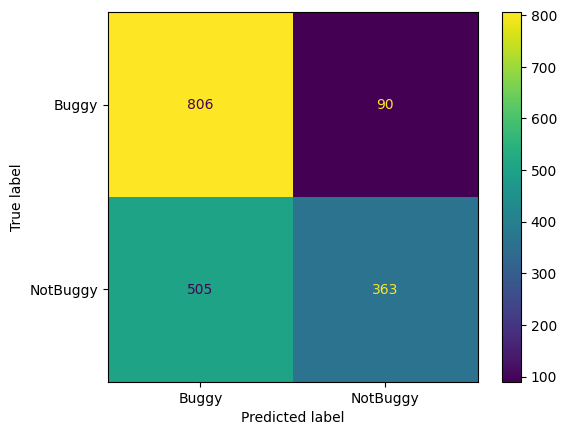

In [9]:
result = pd.read_csv("./Results/RQ1/WithoutMsg/openai-gpt-oss-20b.csv")
result["Output"] = result["Detection"]
            
def extract_result_for_gptoss(text):
    first_word = text
    if "assistantfinal" in text:
        pattern = r"\bassistantfinal\w*"
        first_word = re.findall(pattern, text)[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
    else:
        return None
        
    return first_word if len(first_word) > 0 else None
result["Detection"] = result["Detection"].apply(lambda x: extract_result_for_gptoss(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### OpenAI/GPT-OSS-120B

Accuracy: 0.6672335600907029
Precision: 0.6185725249424405
Recall: 0.8995535714285714
F1 score: 0.7330604820372897
MCC: 0.37205144098725695
              precision    recall  f1-score   support

       Buggy       0.62      0.90      0.73       896
    NotBuggy       0.80      0.43      0.56       868

    accuracy                           0.67      1764
   macro avg       0.71      0.66      0.65      1764
weighted avg       0.71      0.67      0.65      1764



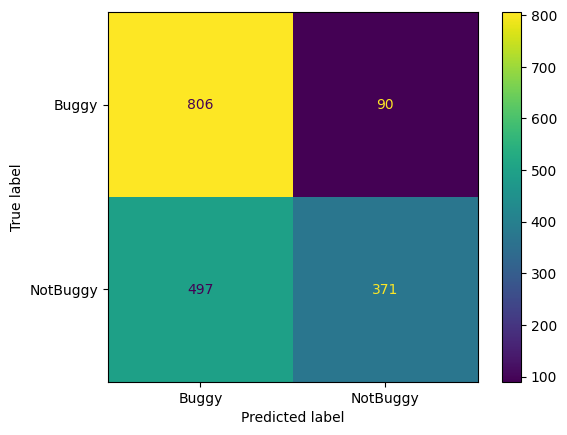

In [9]:
result = pd.read_csv("./Results/RQ1/WithoutMsg/openai-gpt-oss-120b.csv")
result.at[180, "Detection"] = "assistantfinalBuggy"
result["Output"] = result["Detection"]
            
def extract_result_for_gptoss(text):
    first_word = text
    if "assistantfinal" in text:
        pattern = r"\bassistantfinal\w*"
        first_word = re.findall(pattern, text)[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
        elif "NotBug" in first_word:
            first_word = "NotBuggy"
    else:
        return None
        
    return first_word if len(first_word) > 0 else None
result["Detection"] = result["Detection"].apply(lambda x: extract_result_for_gptoss(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### CodeLlama/CodeLlama-7b-instruct-hf

Accuracy: 0.5617913832199547
Precision: 0.5551569506726457
Recall: 0.6908482142857143
F1 score: 0.6156141223272004
MCC: 0.12380262505048367
              precision    recall  f1-score   support

       Buggy       0.56      0.69      0.62       896
    NotBuggy       0.57      0.43      0.49       868

    accuracy                           0.56      1764
   macro avg       0.56      0.56      0.55      1764
weighted avg       0.56      0.56      0.55      1764



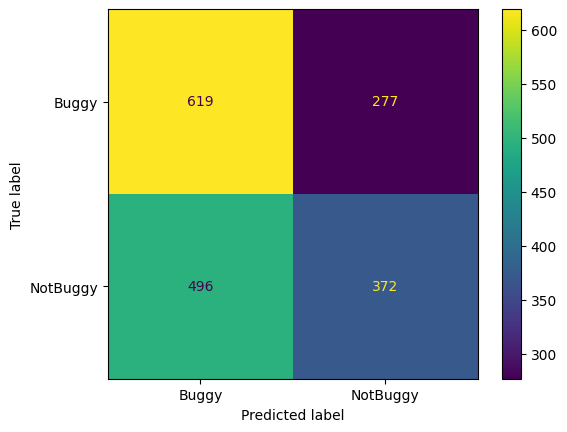

In [ ]:
result = pd.read_csv("./Results/RQ1/WithoutMsg/codellama-CodeLlama-7b-instruct-hf.csv")

print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### CodeLlama/CodeLlama-70b-instruct-hf

In [ ]:
result = pd.read_csv("./Results/RQ1/WithoutMsg/codellama-CodeLlama-70b-Instruct-hf.csv")
result["Output"] = result["Detection"]

patterns = [r"\'(Buggy|NotBuggy)\'", r"\"(Buggy|NotBuggy)\"", r"\*\*(Buggy|NotBuggy)\*\*", r"(Buggy|NotBuggy)", r"\*\*Conclusion:\s*(Buggy|NotBuggy)\*\*", r"\*\*Concluding:\s*(Buggy|NotBuggy)\*\*", r"Final Assessment: (Buggy|NotBuggy)"]

def extract(text, pattern = 0):
    
    if not isinstance(text, str):
        print("Skipping non-string detection:", text)

    if pattern >= len(patterns):
        if "related to a bug fix" in text or "fix a bug" in text or "fixes a bug" in text or "bug-related" in text or "related to the bug fix" in text or "a bug fix" in text or "related to a bug fix" in text or "related to bug fix" in text or "introduces a bug fix" in text or "indicate a bug fix" in text:
            return "Buggy"
        elif "not related to a bug fix" in text:
            return "NotBuggy"
        else:
            return text
        # elif "bug" in text:
        #     return "Buggy"
        # else:
        #     return "NotBuggy"
    
    bold_buggy_words = re.findall(patterns[pattern], text)
    if len(bold_buggy_words) == 0:
        return extract(text, pattern + 1)
    else:
        return ", ".join(set(bold_buggy_words))


result["Detection"] = result["Detection"].apply(lambda x: extract(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

## With Message

### OpenAI/GPT-OSS-20B

Accuracy: 0.8202947845804989
Precision: 0.7577916295636687
Recall: 0.9497767857142857
F1 score: 0.8429915799900941
MCC: 0.6615060689536474
              precision    recall  f1-score   support

       Buggy       0.76      0.95      0.84       896
    NotBuggy       0.93      0.69      0.79       868

    accuracy                           0.82      1764
   macro avg       0.84      0.82      0.82      1764
weighted avg       0.84      0.82      0.82      1764



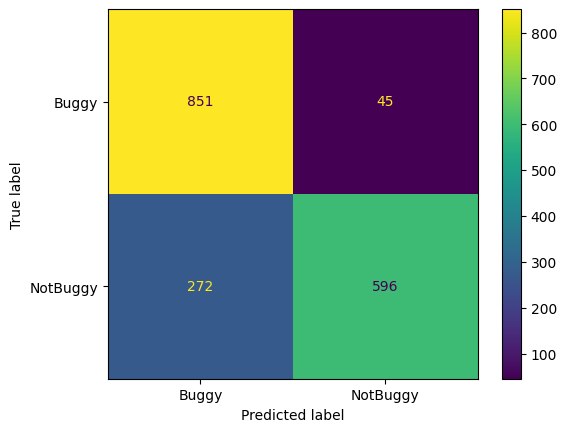

In [44]:
result = pd.read_csv("./Results/RQ1/WithMsg/openai-gpt-oss-20b.csv")
result["Explanation"] = result["Detection"]
            
def extract_result_for_gptoss(text):
    first_word = text
    if "assistantfinal" in text:
        pattern = r"\bassistantfinal\w*"
        first_word = re.findall(pattern, text)[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
    else:
        return None
        
    return first_word if len(first_word) > 0 else None

result["Detection"] = result["Detection"].apply(lambda x: extract_result_for_gptoss(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### OpenAI/GPT-OSS-120B

Accuracy: 0.826530612244898
Precision: 0.766245487364621
Recall: 0.9475446428571429
F1 score: 0.8473053892215568
MCC: 0.6714940633129526
              precision    recall  f1-score   support

       Buggy       0.77      0.95      0.85       896
    NotBuggy       0.93      0.70      0.80       868

    accuracy                           0.83      1764
   macro avg       0.85      0.82      0.82      1764
weighted avg       0.85      0.83      0.82      1764



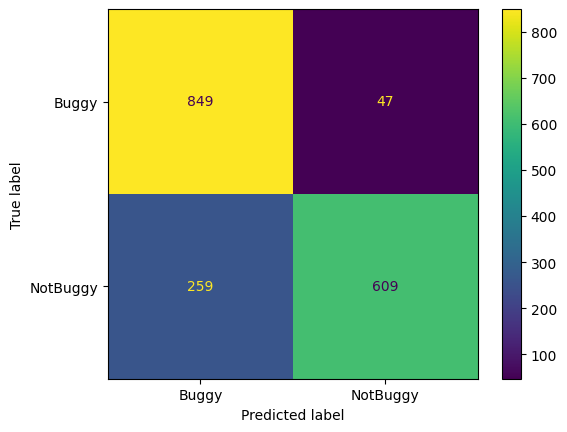

In [25]:
result = pd.read_csv("./Results/RQ1/WithMsg/openai-gpt-oss-120b.csv")
result.at[180, "Detection"] = "assistantfinalBuggy"
result["Output"] = result["Detection"]
            
def extract_result_for_gptoss(text):
    first_word = text
    if "assistantfinal" in text:
        pattern = r"\bassistantfinal\w*"
        first_word = re.findall(pattern, text)[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
        elif "NotBug" in first_word:
            first_word = "NotBuggy"
    else:
        return None
        
    return first_word if len(first_word) > 0 else None
result["Detection"] = result["Detection"].apply(lambda x: extract_result_for_gptoss(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### CodeLlama/CodeLlama-7b-instruct-hf

Accuracy: 0.6751700680272109
Precision: 0.667705088265836
Recall: 0.7176339285714286
F1 score: 0.6917697686928456
MCC: 0.35040716271763267
              precision    recall  f1-score   support

       Buggy       0.67      0.72      0.69       896
    NotBuggy       0.68      0.63      0.66       868

    accuracy                           0.68      1764
   macro avg       0.68      0.67      0.67      1764
weighted avg       0.68      0.68      0.67      1764



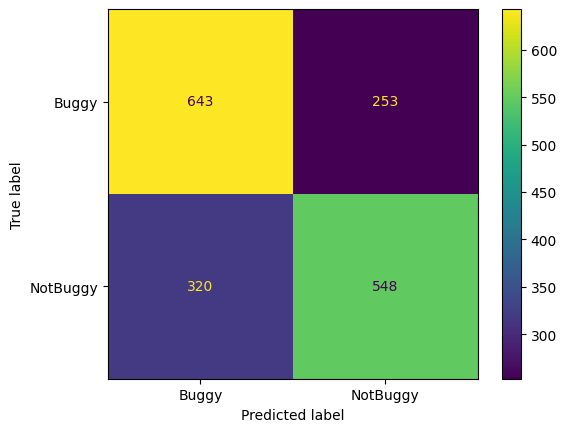

In [26]:
result = pd.read_csv("./Results/RQ1/WithMsg/codellama-CodeLlama-7b-instruct-hf.csv")

print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### CodeLlama/CodeLlama-70b-instruct-hf

In [ ]:
result = pd.read_csv("./Results/RQ1/WithMsg/codellama-CodeLlama-70b-Instruct-hf.csv")
result["Output"] = result["Detection"]

patterns = [r"\'(Buggy|NotBuggy)\'", r"\"(Buggy|NotBuggy)\"", r"\*\*(Buggy|NotBuggy)\*\*", r"(Buggy|NotBuggy)", r"\*\*Conclusion:\s*(Buggy|NotBuggy)\*\*", r"\*\*Concluding:\s*(Buggy|NotBuggy)\*\*", r"Final Assessment: (Buggy|NotBuggy)"]

def extract(text, pattern = 0):
    
    if not isinstance(text, str):
        print("Skipping non-string detection:", text)

    if pattern >= len(patterns):
        if "related to a bug fix" in text or "fix a bug" in text or "fixes a bug" in text or "bug-related" in text or "related to the bug fix" in text or "a bug fix" in text or "related to a bug fix" in text or "related to bug fix" in text or "introduces a bug fix" in text or "indicate a bug fix" in text:
            return "Buggy"
        elif "not related to a bug fix" in text:
            return "NotBuggy"
        else:
            return text
        # elif "bug" in text:
        #     return "Buggy"
        # else:
        #     return "NotBuggy"
    
    bold_buggy_words = re.findall(patterns[pattern], text)
    if len(bold_buggy_words) == 0:
        return extract(text, pattern + 1)
    else:
        return ", ".join(set(bold_buggy_words))


result["Detection"] = result["Detection"].apply(lambda x: extract(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

# RQ2

## FewShot

### OpenAI/GPT-OSS-20B

Accuracy: 0.8373015873015873
Precision: 0.7750677506775068
Recall: 0.9575892857142857
F1 score: 0.8567149276085871
MCC: 0.6935863278030366
              precision    recall  f1-score   support

       Buggy       0.78      0.96      0.86       896
    NotBuggy       0.94      0.71      0.81       868

    accuracy                           0.84      1764
   macro avg       0.86      0.84      0.83      1764
weighted avg       0.86      0.84      0.83      1764



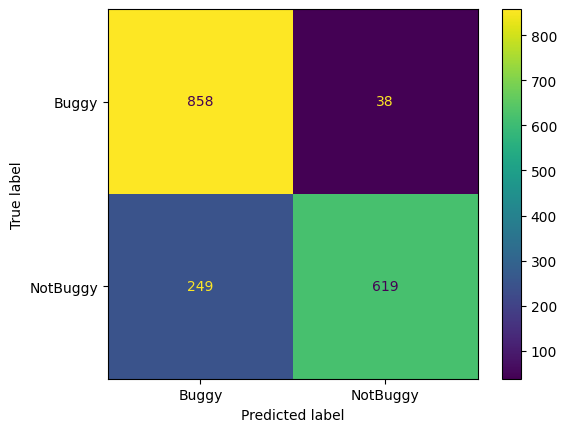

In [18]:
result = pd.read_csv("./Results/RQ2/FewShot/openai-gpt-oss-20b.csv")
result["Explanation"] = result["Detection"]
            
def extract_result_for_gptoss(text):
    first_word = text
    if "assistantfinal" in text or "final" in text:
        pattern = r"assistantfinal\w*"
        words = re.findall(pattern, text)
        if len(words) == 0:
            pattern = r"final:\s*(.+)$"
            words = re.findall(pattern, text)
            if len(words) == 0:
                return text
        first_word = words[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
    else:
        return text
        
    return first_word if len(first_word) > 0 else None

result["Detection"] = result["Detection"].apply(lambda x: extract_result_for_gptoss(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### OpenAI/GPT-OSS-120B

Accuracy: 0.8191609977324263
Precision: 0.7528483786152498
Recall: 0.9587053571428571
F1 score: 0.8433971526755032
MCC: 0.66296919270906
              precision    recall  f1-score   support

       Buggy       0.75      0.96      0.84       896
    NotBuggy       0.94      0.68      0.79       868

    accuracy                           0.82      1764
   macro avg       0.85      0.82      0.81      1764
weighted avg       0.85      0.82      0.82      1764



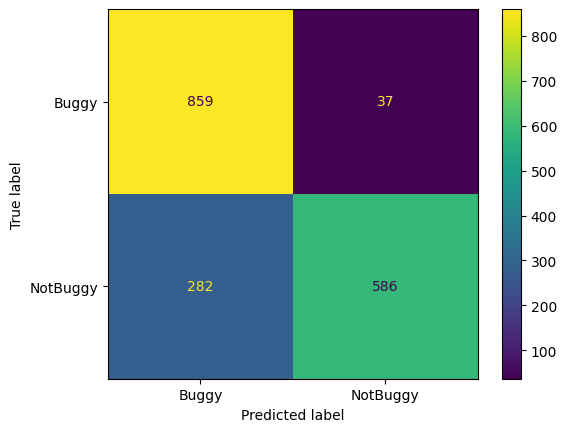

In [ ]:
result = pd.read_csv("./Results/RQ2/FewShot/openai-gpt-oss-120b.csv")
result.at[180, "Detection"] = "assistantfinalBuggy"
result["Output"] = result["Detection"]
            
def extract_result_for_gptoss(text):
    first_word = text
    if "assistantfinal" in text:
        pattern = r"\bassistantfinal\w*"
        first_word = re.findall(pattern, text)[0].replace("assistantfinal", "")
        if first_word == "Bug":
            first_word = "Buggy"
        elif first_word == "NotBug":
            first_word = "NotBuggy"
        elif "NotBug" in first_word:
            first_word = "NotBuggy"
    else:
        return None
        
    return first_word if len(first_word) > 0 else None
result["Detection"] = result["Detection"].apply(lambda x: extract_result_for_gptoss(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### CodeLlama/CodeLlama-7b-instruct-hf

In [7]:
result

,Project,File,CommitHash,Diff,Decision,CommitMessage,text,Detection,Output
0,spring-boot,9232.json,ed15f742fd4eacc14b06908112ac4ca6ae4c0f90,"@@ -1,7 +1,7 @@\r\n \tpublic static String tem...",Buggy,Fix bug in GroovyTemplate convenience\r\n\r\nI...,CommitMessage: Fix bug in GroovyTemplate conve...,NotBuggy,NotBuggy. The code in the diff is correct. T...
1,spring-boot,9233.json,ed15f742fd4eacc14b06908112ac4ca6ae4c0f90,"@@ -1,17 +1,16 @@\r\n-\tprivate static Templat...",Buggy,Fix bug in GroovyTemplate convenience\r\n\r\nI...,CommitMessage: Fix bug in GroovyTemplate conve...,The commit message indicates that a bug was ...,The commit message indicates that a bug was ...
2,spring-boot,510.json,99ae6dac5321a741d93ff5187fafb94c295a6928,"@@ -1,3 +1,3 @@\r\n-\t\tpublic CouchbaseEnviro...",Buggy,Customize Couchbase's socket connect timeout\r...,CommitMessage: Customize Couchbase's socket co...,This commit message describes a fix for a bu...,This commit message describes a fix for a bu...
3,spring-boot,516.json,99ae6dac5321a741d93ff5187fafb94c295a6928,"@@ -1,22 +1,23 @@\r\n-\t\tprotected CouchbaseE...",Buggy,Customize Couchbase's socket connect timeout\r...,CommitMessage: Customize Couchbase's socket co...,"This commit message is clear and concise, an...","This commit message is clear and concise, an..."
4,spring-boot,6313.json,1a2186e6efed5c53d7c50548de7b30b9a6dcd7f7,"@@ -1,6 +1,6 @@\r\n \t\tprivate boolean starts...",Buggy,Attempt to fix lambda error detection on JDK 9...,CommitMessage: Attempt to fix lambda error det...,This commit message is not clear and does no...,This commit message is not clear and does no...
...,...,...,...,...,...,...,...,...,...
1759,titan,2713.json,51075f047f33c09c17c33f7e61fcf859c815ed52,"@@ -1,5 +1,6 @@\r\n- protected void verifyA...",NotBuggy,Updated to new TP3\r\n,CommitMessage: Updated to new TP3\r\n\r\nDiff:...,"The commit message ""Updated to new TP3"" does...","The commit message ""Updated to new TP3"" does..."
1760,titan,2620.json,aead96abd7152d9843e25578fd640dbbdaa8b765,"@@ -1,3 +1,3 @@\r\n public Iterable<Edge> ...",NotBuggy,Intermediate big bang commit\r\n,CommitMessage: Intermediate big bang commit\r\...,This commit message indicates that the devel...,This commit message indicates that the devel...
1761,titan,4872.json,ae15683f30b52b053cb7c62c6bd9162e374f62a4,"@@ -1,12 +1,12 @@\r\n-\tpublic static final lo...",NotBuggy,big fatty refactor -- tests do not pass.\r\n,CommitMessage: big fatty refactor -- tests do ...,Buggy,Buggy
1762,titan,4164.json,7f94323100a007d1f346b163485b14a43a53dd4c,"@@ -1,3 +1,3 @@\r\n public int getLimit() ...",NotBuggy,Updated optimizers to include PropertyStep. Re...,CommitMessage: Updated optimizers to include P...,The commit message suggests that the optimiz...,The commit message suggests that the optimiz...


In [6]:
result = pd.read_csv("./Results/RQ2/FewShot/codellama-CodeLlama-7b-Instruct-hf.csv")
result["Output"] = result["Detection"]

patterns = [r"\'(Buggy|NotBuggy)\'", r"\"(Buggy|NotBuggy)\"", r"\*\*(Buggy|NotBuggy)\*\*", r"(Buggy|NotBuggy)", r"\*\*Conclusion:\s*(Buggy|NotBuggy)\*\*", r"\*\*Concluding:\s*(Buggy|NotBuggy)\*\*", r"Final Assessment: (Buggy|NotBuggy)"]

def extract(text, pattern = 0):
    
    if not isinstance(text, str):
        print("Skipping non-string detection:", text)

    if pattern >= len(patterns):
        if "related to a bug fix" in text or "fix a bug" in text or "fixes a bug" in text or "bug-related" in text or "related to the bug fix" in text or "a bug fix" in text or "related to a bug fix" in text or "related to bug fix" in text or "introduces a bug fix" in text or "indicate a bug fix" in text:
            return "Buggy"
        elif "not related to a bug fix" in text:
            return "NotBuggy"
        else:
            return text
        # elif "bug" in text:
        #     return "Buggy"
        # else:
        #     return "NotBuggy"
    
    bold_buggy_words = re.findall(patterns[pattern], text)
    if len(bold_buggy_words) == 0:
        return extract(text, pattern + 1)
    else:
        return ", ".join(set(bold_buggy_words))


result["Detection"] = result["Detection"].apply(lambda x: extract(x))
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

Accuracy: 0.3168934240362812


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

### CodeLlama/CodeLlama-70b-instruct-hf

## COT

### OpenAI/GPT-OSS-20B

Accuracy: 0.828798185941043
Precision: 0.7651785714285714
Recall: 0.9564732142857143
F1 score: 0.8501984126984127
MCC: 0.6785670631750276
              precision    recall  f1-score   support

       Buggy       0.77      0.96      0.85       896
    NotBuggy       0.94      0.70      0.80       868

    accuracy                           0.83      1764
   macro avg       0.85      0.83      0.83      1764
weighted avg       0.85      0.83      0.83      1764



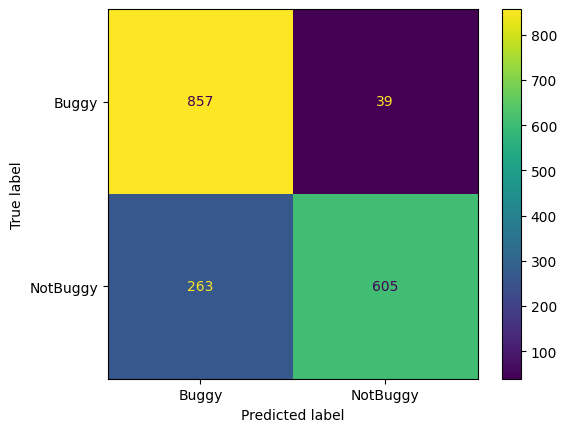

In [29]:
result = pd.read_csv("./Results/RQ2/COT/openai-gpt-oss-20b-processed.csv")

print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### OpenAI/GPT-OSS-120B

Accuracy: 0.8293650793650794
Precision: 0.7702089009990918
Recall: 0.9464285714285714
F1 score: 0.8492739108662994
MCC: 0.6760427933933968
              precision    recall  f1-score   support

       Buggy       0.77      0.95      0.85       896
    NotBuggy       0.93      0.71      0.80       868

    accuracy                           0.83      1764
   macro avg       0.85      0.83      0.83      1764
weighted avg       0.85      0.83      0.83      1764



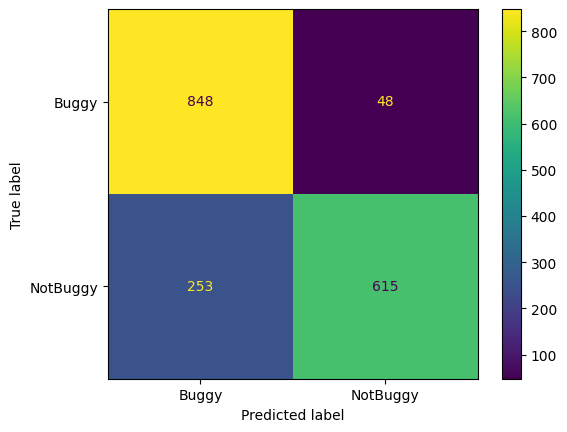

In [47]:
result = pd.read_csv("./Results/RQ2/COT/openai-gpt-oss-120b-processed.csv")

print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### CodeLlama/CodeLlama-7b-instruct-hf

In [ ]:
result = pd.read_csv("./Results/RQ2/COT/codellama-CodeLlama-7b-Instruct-hf.csv")

print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### CodeLlama/CodeLlama-70b-instruct-hf

## FewShot+COT

### OpenAI/GPT-OSS-20B

Accuracy: 0.8435374149659864
Precision: 0.7952380952380952
Recall: 0.9319196428571429
F1 score: 0.8581706063720452
MCC: 0.6968964984856202
              precision    recall  f1-score   support

       Buggy       0.80      0.93      0.86       896
    NotBuggy       0.91      0.75      0.83       868

    accuracy                           0.84      1764
   macro avg       0.85      0.84      0.84      1764
weighted avg       0.85      0.84      0.84      1764



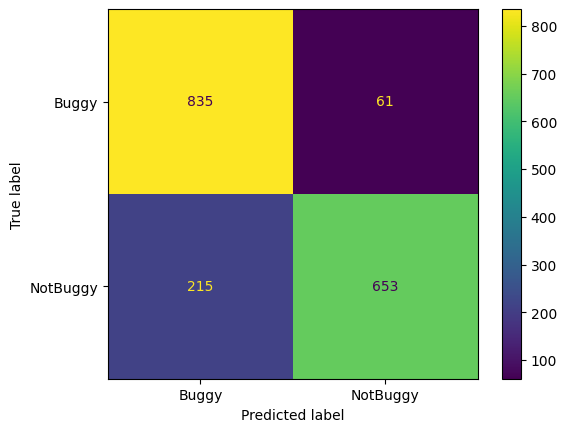

In [115]:
result = pd.read_csv("./Results/RQ2/FewShotCOT/openai-gpt-oss-20b.csv")
result["Detection"] = result.apply(lambda x: extract_result_for_gptoss(x), axis=1)
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### OpenAI/GPT-OSS-120B

Accuracy: 0.8157596371882087
Precision: 0.7515418502202643
Recall: 0.9520089285714286
F1 score: 0.8399803052683407
MCC: 0.654551962921865
              precision    recall  f1-score   support

       Buggy       0.75      0.95      0.84       896
    NotBuggy       0.93      0.68      0.78       868

    accuracy                           0.82      1764
   macro avg       0.84      0.81      0.81      1764
weighted avg       0.84      0.82      0.81      1764



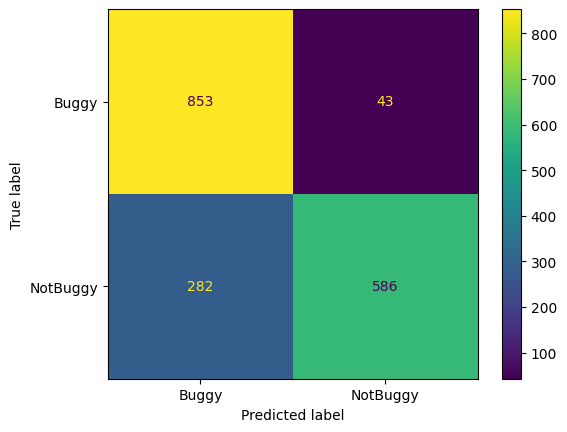

In [56]:
result = pd.read_csv("./Results/RQ2/FewShotCOT/openai-gpt-oss-120b.csv")
result.at[180, "Explanation"] = "assistantfinalBuggy"
result["Detection"] = result.apply(lambda x: extract_result_for_gptoss(x), axis=1)
print("Accuracy:", accuracy_score(result["Decision"], result["Detection"]))
print("Precision:", precision_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("Recall:", recall_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("F1 score:", f1_score(result["Decision"], result["Detection"], pos_label="Buggy"))
print("MCC:", matthews_corrcoef(result["Decision"], result["Detection"]))
print(classification_report(result["Decision"], result["Detection"]))
cm = confusion_matrix(result["Decision"], result["Detection"], labels=["Buggy", "NotBuggy"])
fig = ConfusionMatrixDisplay(cm, display_labels=["Buggy", "NotBuggy"])
fig.plot()

### CodeLlama/CodeLlama-7b-instruct-hf

### CodeLlama/CodeLlama-70b-instruct-hf